---
# 3.2 Bisection method
---

Suppose $f \in C[a,b]$ and that $f(a)$ and $f(b)$ have opposite signs; i.e.,

$$
f(a) \cdot f(b) < 0.
$$

Recall the following important theorem from calculus.

> ### Intermediate Value Theorem
>
> If $f \in C[a,b]$ and $f(a) \leq s \leq f(b)$, then there exists a real number $c \in [a,b]$ such that $f(c) = s$.

Since $f$ changes sign over $[a,b]$, the Intermediate Value Theorem implies that there is some $x^* \in [a,b]$ such that $f(x^*) = 0$.

The **bisection method** searches for a root of $f$ in $[a,b]$ as follows.

1. Let $p = (a+b)/2$ be the **midpoint** of $[a,b]$.
2. If $f(a) \cdot f(p) < 0$, then there is a root in $[a,p]$.
3. If $f(a) \cdot f(p) = 0$, then $p$ is a root.
4. If $f(a) \cdot f(p) > 0$, then there is a root in $[p,b]$.

Each time we apply the above, we get a subinterval that contains a root that is **half the size** of the interval $[a,b]$.

In [47]:
# Code the bisection method
# Hint: use the signbit function

function bisect(f, a, b; maxiters=100, tol=eps())
    fa, fb = f(a), f(b)

    if a >= b
        error("Need to have a < b.")
    end
    
    if signbit(fa) == signbit(fb)
        error("The signs of f(a) and f(b) must be different.")
    end

    k = 0
    p = 0.0
    while true
        # signbit(fa) != signbit(fb)
        k +=1
        
        p = (a + b)/2
        fp = f(p)

        # @show (b - a)/2
        # |p - x^*| <= (b - a)/2
        if (abs(fp) <= tol 
                || (b - a)/2 <= tol
                || nextfloat(a) == b
                || k == maxiters)
            break
        end

        if signbit(fa) != signbit(fp)      # Root is in [a, p]
            b = p
        else # signbit(fb) != signbit(fp)  # Root is in [p, b]
            a = p
        end
        # @show p
    end
    println("k = ", k)

    return p
end

f(x) = x^2 - 2
a, b = 1.0, 2.0

p = bisect(f, a, b, tol=1e-6)

p, f(p)

k = 20


(1.4142141342163086, 1.6174171832972206e-6)

In [41]:
p = bisect(f, a, b, tol=1e-15)
abs(p - sqrt(2))

k = 50


2.220446049250313e-16

In [42]:
eps()

2.220446049250313e-16

In [43]:
p = bisect(f, a, b, tol=0.0)
abs(p - sqrt(2))

k = 53


2.220446049250313e-16

In [44]:
sqrt(2)

1.4142135623730951

In [45]:
bitstring(p)

"0011111111110110101000001001111001100110011111110011101111001100"

In [46]:
bitstring(sqrt(2))

"0011111111110110101000001001111001100110011111110011101111001101"

In [3]:
f(a)

-1.0

In [4]:
f(b)

2.0

---

### Example

We will now use the above `bisect` function to find the root of

$$
f(x) = 2 \cosh(x/4) - x
$$

that lies in the interval $[5,10]$.

In [48]:
f(x) = 2cosh(x/4) - x
a, b = 5.0, 10.0

p = bisect(f, a, b, tol=0.0)
p, f(p)

k = 53


(8.507199570713027, 1.7763568394002505e-15)

---

### Example

Let's try to find the value of $y_0$ such that the solution $y(t)$ of the ordinary differential equation 

$$
\frac{dy}{dt} = t - 5 + \frac{y^2}{100}
$$

with initial value $y(0) = y_0$ satisfies $y(10) = 20$.

In [49]:
using OrdinaryDiffEq  # Package for solving ordinary differential equations
using Plots, LaTeXStrings

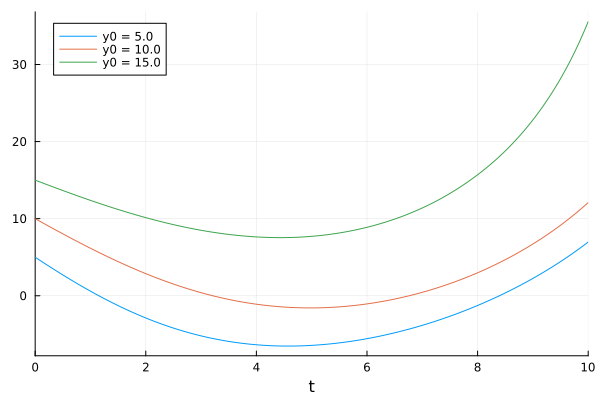

In [50]:
f(y, p, t) = t - 5 + y^2/100

function foo(y0)
    tspan = (0.0, 10.0)
    prob = ODEProblem(f, y0, tspan)
    sol = solve(prob, Tsit5())
end

initial_values = [5.0, 10.0, 15.0]
plot()
for y0 in initial_values
    sol = foo(y0)
    plot!(sol, label="y0 = $(y0)")
end
plot!()

In [51]:
function f(y0)
    sol = foo(y0)
    return sol(10.0) - 20.0
end

f (generic function with 2 methods)

In [52]:
f(10.0)

-7.912152417475296

In [53]:
f(15.0)

15.574382263182109

In [54]:
p = bisect(f, 10.0, 15.0, tol=0.0)

k = 52


12.932932907322336

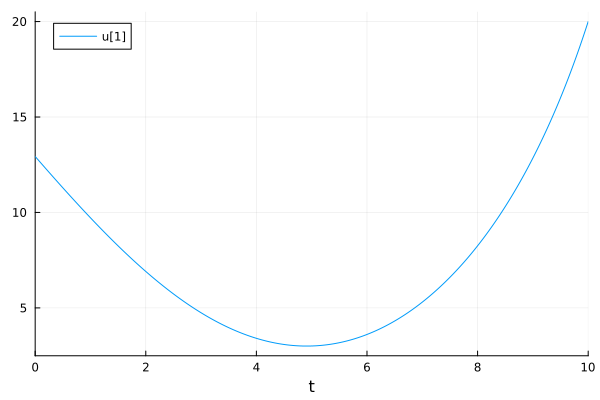

In [56]:
sol = foo(p)
plot(sol)

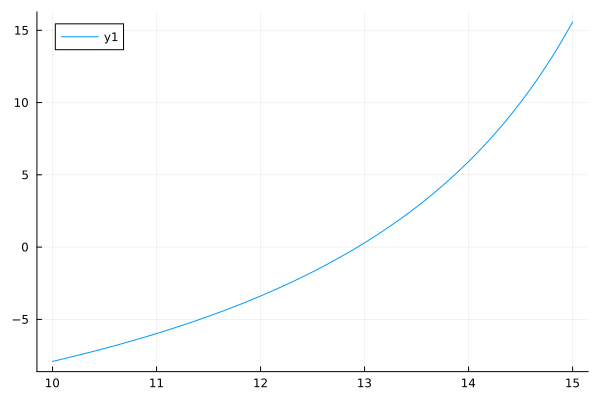

In [57]:
plot(f, 10.0, 15.0)

---

## Analyzing the bisection method

Initially, we know a root $x^*$ is somewhere in the interval $[a,b]$. If we let $x_k$ be the midpoint of the $k$th subinterval, then

$$\left|x^* - x_0\right| \leq \frac{b-a}{2}.$$

In the next iteration, 

$$\left|x^* - x_1\right| \leq \frac{b-a}{4},$$

and in the following iteration,

$$\left|x^* - x_2\right| \leq \frac{b-a}{8},$$

and so on, each time reducing our error bound by a factor of $2$.

In general,

$$\left|x^* - x_k\right| \leq \frac{b-a}{2} \cdot 2^{-k}, 
\qquad \text{for $k = 0,1,2,\ldots$}.$$

Suppose we want to compute $x_k$ such that 

$$\left|x^* - x_k\right| \leq \mathtt{atol}.$$

Then we just need to find the smallest positive integer $k$ such that

$$\frac{b-a}{2} \cdot 2^{-k} \leq \mathtt{atol}.$$

That is,

$$\frac{b-a}{2\mathtt{atol}} \leq 2^k,$$

which gives us

$$\log_2\left(\frac{b-a}{2\mathtt{atol}}\right) \leq k,$$

so we just need the first integer $k$ that is larger than $\log_2\left(\frac{b-a}{2\mathtt{atol}}\right)$. Therefore, 

$$k = \left\lceil \log_2\left(\frac{b-a}{2\mathtt{atol}}\right) \right\rceil.$$

---

## Pros and cons of the bisection method

Pros:

1. **Simple:** The bisection method only requires function values, is easy to understand and implement, and it is easy to analyze.

2. **Robust:** The bisection method is guaranteed to work, provided that $f$ is continuous and changes sign on the interval $[a,b]$.

Cons:

1. **Slow to converge:** The bisection method often requires many function evaluations.

2. **Does not generalize:** The bisection method only applies to solving equations involving one variable; it does not generalize to solving equations involving multiple variables.



---